In [1]:
# ΚΕΛΙ 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Εισαγωγή των δικών σου συναρτήσεων
from utils import list_files_in_folder, encode_labels
from utils_visual import plot_heatmap, plot_instance_3d, plot_scatter_pca

# Ρύθμιση για να φαίνονται τα γραφήματα μέσα στο notebook
%matplotlib inline

In [2]:
# ΚΕΛΙ 2
folder_path = './MachineLearningCSV'
files = list_files_in_folder(folder_path)

# Φόρτωση ενός αρχείου
df = pd.read_csv(os.path.join(folder_path, files[1]))

# Καθαρισμός ονομάτων στηλών (πολύ σημαντικό!)
df.columns = df.columns.str.strip()

# Εμφάνιση των πρώτων γραμμών και των τύπων δεδομένων
print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 286467 entries, 0 to 286466
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             286467 non-null  int64  
 1   Flow Duration                286467 non-null  int64  
 2   Total Fwd Packets            286467 non-null  int64  
 3   Total Backward Packets       286467 non-null  int64  
 4   Total Length of Fwd Packets  286467 non-null  int64  
 5   Total Length of Bwd Packets  286467 non-null  int64  
 6   Fwd Packet Length Max        286467 non-null  int64  
 7   Fwd Packet Length Min        286467 non-null  int64  
 8   Fwd Packet Length Mean       286467 non-null  float64
 9   Fwd Packet Length Std        286467 non-null  float64
 10  Bwd Packet Length Max        286467 non-null  int64  
 11  Bwd Packet Length Min        286467 non-null  int64  
 12  Bwd Packet Length Mean       286467 non-null  float64
 13  Bwd Packet

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
# ΚΕΛΙ 3: 
# Αντικατάσταση inf, μέτρηση και αφαίρεση NaN/Duplicates
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f"Ελλιπείς τιμές: {df.isnull().sum().sum()}")
print(f"Διπλότυπα: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

# Συγκεντρωτικά στατιστικά
display(df.describe())

--- Έλεγχος για Ελλιπείς Τιμές & Διπλότυπα ---
Ελλιπείς τιμές/Inf που βρέθηκαν: 742
Διπλότυπες εγγραφές που βρέθηκαν: 72353

--- Μετά τον Καθαρισμό ---
Τελικές γραμμές: 213777, Τελικές στήλες: 79


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,213777.000000,2.137770e+05,213777.000000,213777.000000,213777.000000,2.137770e+05,213777.000000,213777.000000,213777.000000,213777.000000,...,213777.000000,213777.000000,2.137770e+05,2.137770e+05,2.137770e+05,2.137770e+05,2.137770e+05,2.137770e+05,2.137770e+05,2.137770e+05
mean,7909.796175,7.208383e+06,4.287870,4.382609,311.032253,3.624906e+03,107.865093,13.164068,31.631662,32.942919,...,2.291154,28.210902,4.568439e+04,3.075345e+04,1.043308e+05,2.909708e+04,2.148027e+06,8.201490e+04,2.207276e+06,2.058665e+06
std,15954.964472,2.511763e+07,22.529865,32.702105,2153.651778,5.898361e+04,375.640484,27.163918,89.403911,134.673509,...,17.205268,7.783977,5.388699e+05,3.032478e+05,8.483509e+05,4.886499e+05,9.992221e+06,1.408207e+06,1.022232e+07,9.856408e+06
min,0.000000,-1.300000e+01,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,4.800000e+01,1.000000,1.000000,0.000000,6.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,443.000000,1.170000e+02,1.000000,1.000000,6.000000,6.000000e+00,6.000000,2.000000,6.000000,0.000000,...,0.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,6003.000000,5.115400e+04,2.000000,2.000000,78.000000,1.820000e+02,44.000000,31.000000,41.000000,0.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65389.000000,1.199999e+08,3119.000000,3635.000000,232349.000000,7.150819e+06,13929.000000,1472.000000,3412.938776,3541.466551,...,2056.000000,60.000000,1.100000e+08,7.050000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.050000e+07,1.200000e+08,1.200000e+08


--- Συχνότητα και Ποσοστά Κλάσεων ---
          Αριθμός Εγγραφών  Ποσοστό (%)
Label                                  
BENIGN              123083    57.575417
PortScan             90694    42.424583


C:\Users\spiro\AppData\Local\Temp\ipykernel_27816\1740313796.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label', palette='viridis')


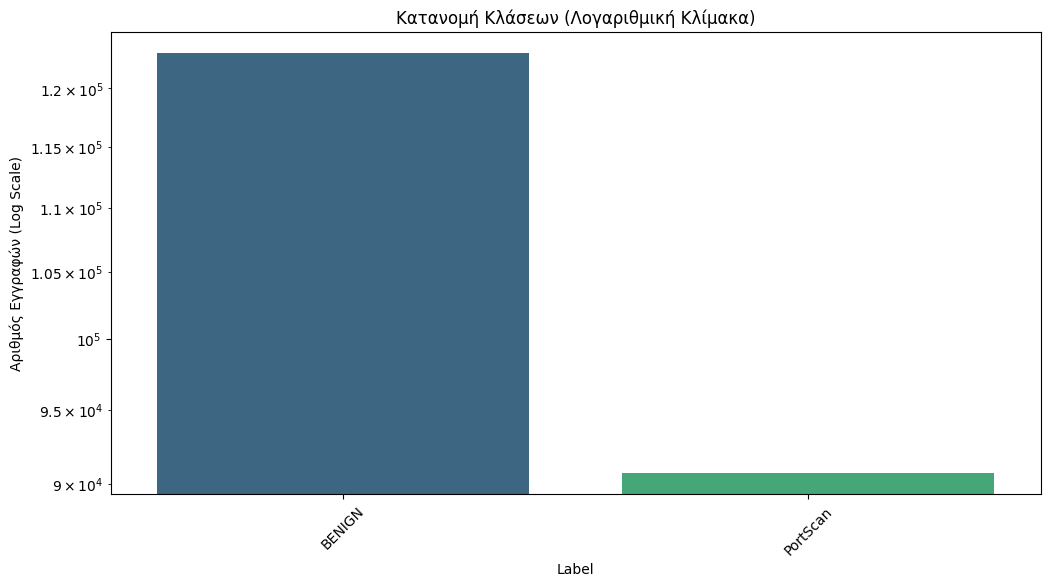

In [ ]:
# ΚΕΛΙ 4
# 1. Heatmap
plot_heatmap(df)
plt.title("Συσχέτιση Χαρακτηριστικών")
plt.show()

# 2. Ανάλυση Label με Log Scale (για την ανισορροπία)
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Label', palette='magma')
plt.yscale('log') 
plt.xticks(rotation=45)
plt.title("Κατανομή Κλάσεων (Log Scale)")
plt.show()

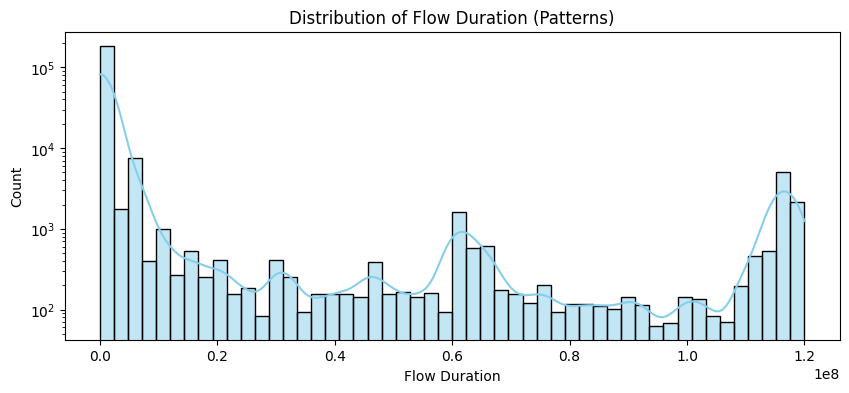

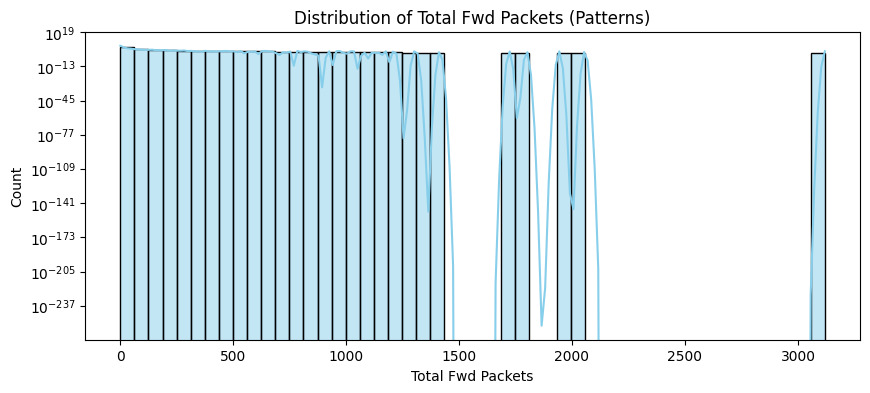

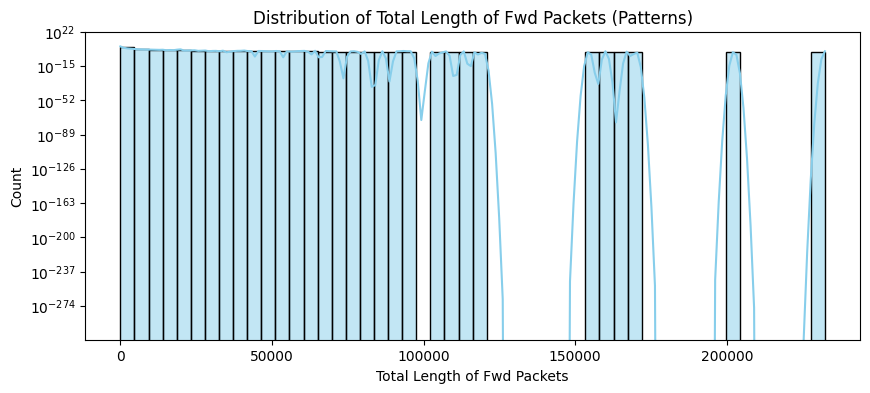

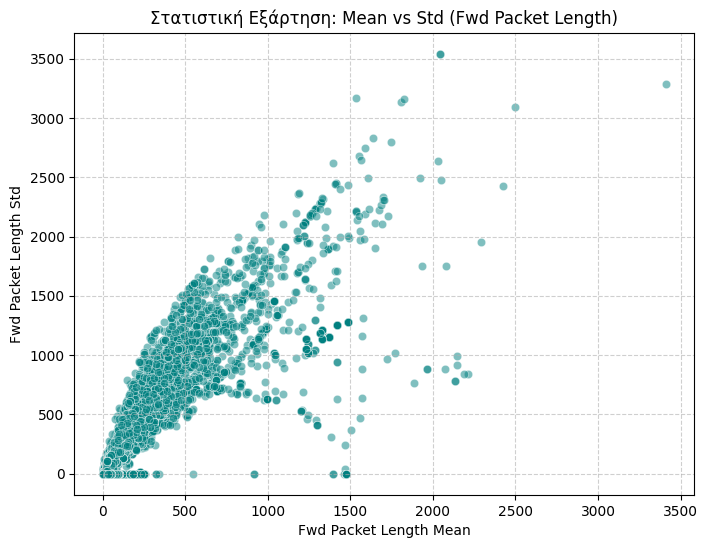

In [ ]:
# ΚΕΛΙ 5: 

# 1. Ιστογράμματα (Μοτίβα)
interesting_cols = ['Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets']
for col in interesting_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=50, kde=True, color='skyblue')
    plt.yscale('log')
    plt.title(f'Distribution of {col}')
    plt.show()

# 2. Σχέση Στατιστικών (Εξαρτήσεις)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Fwd Packet Length Mean', y='Fwd Packet Length Std', alpha=0.5)
plt.title('Σχέση Μέσου Όρου - Τυπικής Απόκλισης')
plt.show()

In [ ]:
# ΚΕΛΙ 6
# Επιλογή χαρακτηριστικών για Boxplot (π.χ. μήκος πακέτων)
# Επιλέγουμε στήλες με παρόμοια κλίμακα για να φαίνονται σωστά στο ίδιο γράφημα
boxplot_cols = ['Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Bwd Packet Length Max']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[boxplot_cols], palette="Set3")
plt.title('Εντοπισμός Ακραίων Τιμών (Boxplots)')
plt.ylabel('Τιμή (Pixels/Bytes)')
plt.show()

,Flow Duration,Fwd Packet Length Mean,Flow Packets/s
Label,,,
BENIGN,1.241298e+07,54.179757,53676.117586
PortScan,1.450965e+05,1.031103,71995.391340


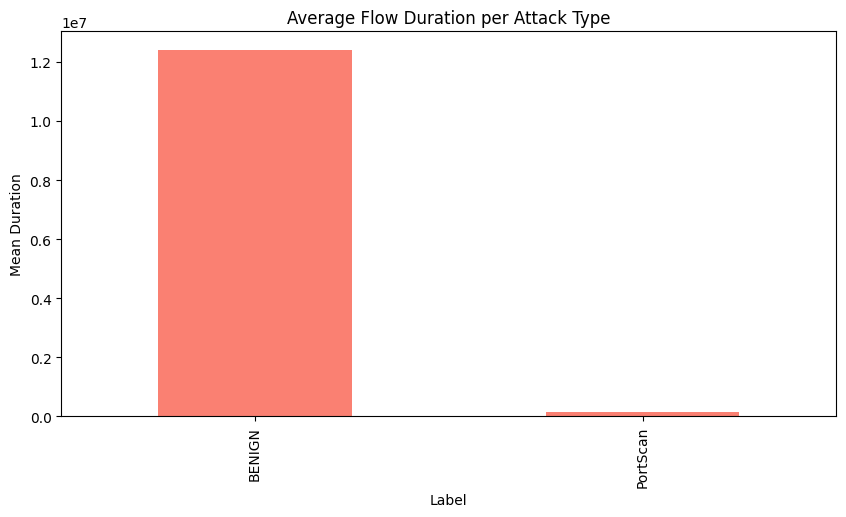

In [ ]:
# ΚΕΛΙ 7
# Ομαδοποίηση ανά Label και υπολογισμός μέσου όρου για βασικά χαρακτηριστικά
grouped_stats = df.groupby('Label')[['Flow Duration', 'Fwd Packet Length Mean', 'Flow Packets/s']].mean()
display(grouped_stats)

# Οπτικοποίηση: Πώς διαφέρει ο μέσος όρος του Flow Duration ανά επίθεση
grouped_stats['Flow Duration'].plot(kind='bar', figsize=(10, 5), color='salmon')
plt.title('Average Flow Duration per Attack Type')
plt.ylabel('Mean Duration')
plt.show()

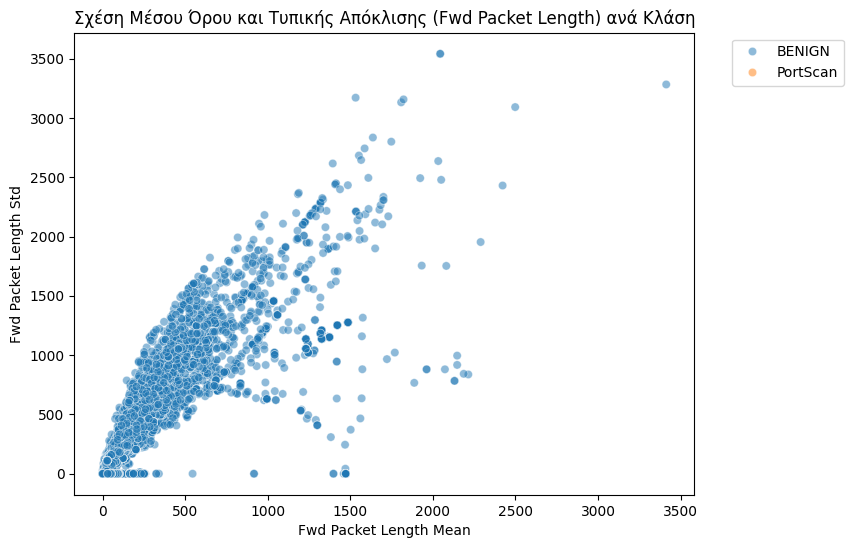

In [ ]:
# ΚΕΛΙ 8
plt.figure(figsize=(8, 6))
# Προσθέτουμε hue='Label' για να δούμε πού βρίσκονται οι επιθέσεις σε αυτή τη σχέση
sns.scatterplot(data=df, x='Fwd Packet Length Mean', y='Fwd Packet Length Std', hue='Label', alpha=0.5)
plt.title('Σχέση Μέσου Όρου και Τυπικής Απόκλισης (Fwd Packet Length) ανά Κλάση')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Για να μην κρύβει το γράφημα η λεζάντα
plt.show()